In [1]:
import pandas as pd
from sklearn import datasets

digits = datasets.load_digits()
df = pd.DataFrame(digits.data, columns=digits.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [2]:
df['target'] = digits.target
df.head(20)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
5,0.0,0.0,12.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,9.0,16.0,16.0,10.0,0.0,0.0,5
6,0.0,0.0,0.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,9.0,15.0,11.0,3.0,0.0,6
7,0.0,0.0,7.0,8.0,13.0,16.0,15.0,1.0,0.0,0.0,...,0.0,0.0,0.0,13.0,5.0,0.0,0.0,0.0,0.0,7
8,0.0,0.0,9.0,14.0,8.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,15.0,11.0,1.0,0.0,8
9,0.0,0.0,11.0,12.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,9.0,12.0,13.0,3.0,0.0,0.0,9


In [3]:
from sklearn.model_selection import train_test_split
X, y = df.drop(columns=['target']).values, df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 1437
Test set size: 360


In [4]:
from sklearn.linear_model import LogisticRegression

reg = 0.01

model = LogisticRegression(C=1/reg, solver='lbfgs', max_iter=10000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        33
           1       0.90      1.00      0.95        28
           2       0.94      0.97      0.96        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.96       360
   macro avg       0.96      0.97      0.96       360
weighted avg       0.96      0.96      0.96       360



In [6]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

print(f"Accuracy: {accuracy_score(y_test, pred)}")
print(f"Recall: {recall_score(y_test, pred, average='weighted')}")
print(f"Precision: {precision_score(y_test, pred, average='weighted')}")

Accuracy: 0.9638888888888889
Recall: 0.9638888888888889
Precision: 0.9647162890521526


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

[[32  0  1  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  1 32  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  1  0  0 45  0  0  0  0  0]
 [ 0  0  1  0  0 44  1  0  0  1]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  1  0  0 29  0]
 [ 0  1  0  1  0  0  0  0  1 37]]


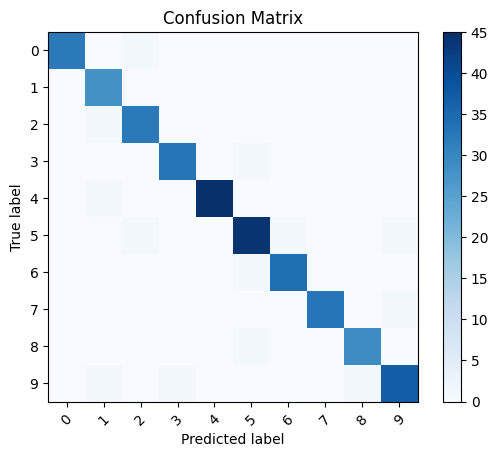

In [8]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.colorbar()

tick_marks = np.arange(len(digits.target_names))
plt.xticks(tick_marks, digits.target_names, rotation=45)
plt.yticks(tick_marks, digits.target_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

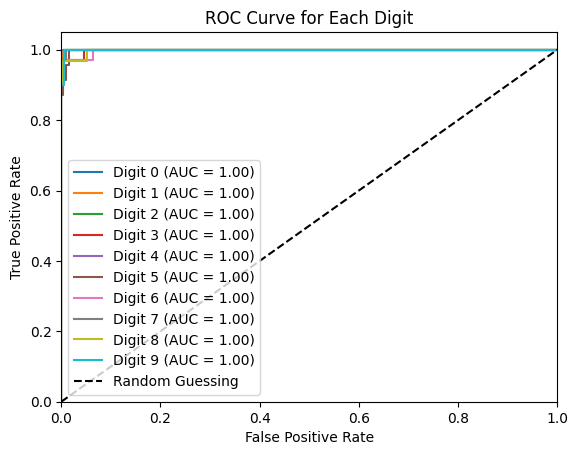

In [9]:
from sklearn.metrics import roc_auc_score, roc_curve

digit_prob = model.predict_proba(X_test)

fpr = {}
tpr = {}
thresh = {}

for i in range(len(digits.target_names)):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test == i, digit_prob[:, i])
    auc_score = roc_auc_score(y_test == i, digit_prob[:, i])
    plt.plot(fpr[i], tpr[i], label=f'Digit {i} (AUC = {auc_score:.2f})' )

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Digit')
plt.legend(loc='best')
plt.show()

In [10]:
auc = roc_auc_score(y_test, digit_prob, multi_class='ovr')
print(f"Overall AUC: {auc}")

Overall AUC: 0.9991990952365926


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

feature_columns = list(range(len(df.columns) - 1))

feature_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('preprocess', feature_transformer, feature_columns)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVC(probability=True))
])

multi_model = pipeline.fit(X_train, y_train)
print(multi_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('preprocess',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15, 16,
                                                   17, 18, 19, 20, 21, 22, 23,
                                                   24, 25, 26, 27, 28, 29, ...])])),
                ('regressor', SVC(probability=True))])


Overall Accuracy: 0.9805555555555555
Overall Recall: 0.9805555555555555
Overall Precision: 0.9809087132003798
Overall AUC: 0.9996105515588853


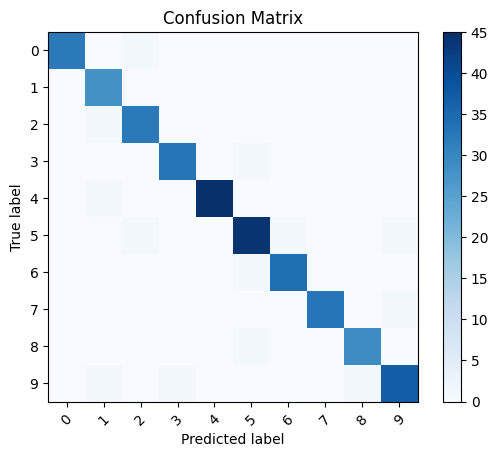

In [12]:
digit_pred = multi_model.predict(X_test)

digit_prob = multi_model.predict_proba(X_test)

print(f"Overall Accuracy: {accuracy_score(y_test, digit_pred)}")
print(f"Overall Recall: {recall_score(y_test, digit_pred, average='weighted')}")
print(f"Overall Precision: {precision_score(y_test, digit_pred, average='weighted')}")
print(f"Overall AUC: {roc_auc_score(y_test, digit_prob, multi_class='ovr')}")

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

plt.colorbar()

tick_marks = np.arange(len(digits.target_names))

plt.xticks(tick_marks, digits.target_names, rotation=45)
plt.yticks(tick_marks, digits.target_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

In [13]:
import joblib

filename = 'digits_model.pkl'
joblib.dump(multi_model, filename)

['digits_model.pkl']

In [14]:
print(f"AUC Score: {roc_auc_score(y_test, digit_prob, multi_class='ovr')}")

AUC Score: 0.9996105515588853
